<a href="https://colab.research.google.com/github/projectsofiqbal/Vehicle-Deliveries-Production-Trend-Analysis/blob/main/Vehicle_Deliveries_%26_Production_Trend_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df=pd.read_csv(r"/content/tesla_deliveries_dataset_2015_2025.csv")

In [ ]:
df

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722
...,...,...,...,...,...,...,...,...,...,...,...,...
2635,2021,10,Middle East,Model Y,13488,14333,113771.10,120,719,1454.68,Official (Quarter),4273
2636,2019,7,Middle East,Model S,18300,18407,81889.67,82,487,1336.81,Official (Quarter),9833
2637,2019,9,Asia,Model S,13291,14839,97139.38,100,580,1156.32,Estimated (Region),13709
2638,2020,5,Asia,Cybertruck,3471,3714,69990.57,60,358,186.39,Interpolated (Month),6754


In [ ]:
df.dtypes

,0
Year,int64
Month,int64
Region,object
Model,object
Estimated_Deliveries,int64
Production_Units,int64
Avg_Price_USD,float64
Battery_Capacity_kWh,int64
Range_km,int64
CO2_Saved_tons,float64


In [ ]:
df.isnull().sum()

,0
Year,0
Month,0
Region,0
Model,0
Estimated_Deliveries,0
Production_Units,0
Avg_Price_USD,0
Battery_Capacity_kWh,0
Range_km,0
CO2_Saved_tons,0


In [ ]:
df.describe()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


In [ ]:
df["Year"] = df["Year"].astype("object")
df["Month"] = df["Month"].astype("object")


In [ ]:
df.describe()

,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


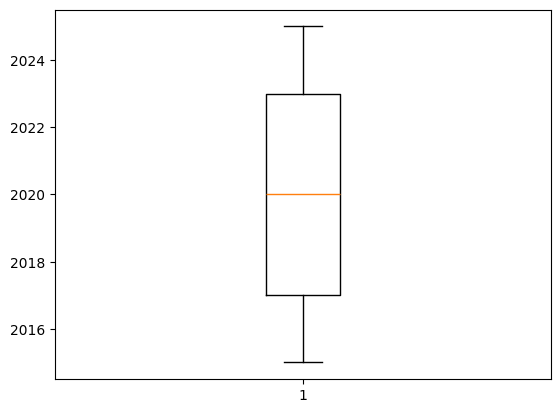

In [ ]:
plt.boxplot(df['Year'])
plt.show()

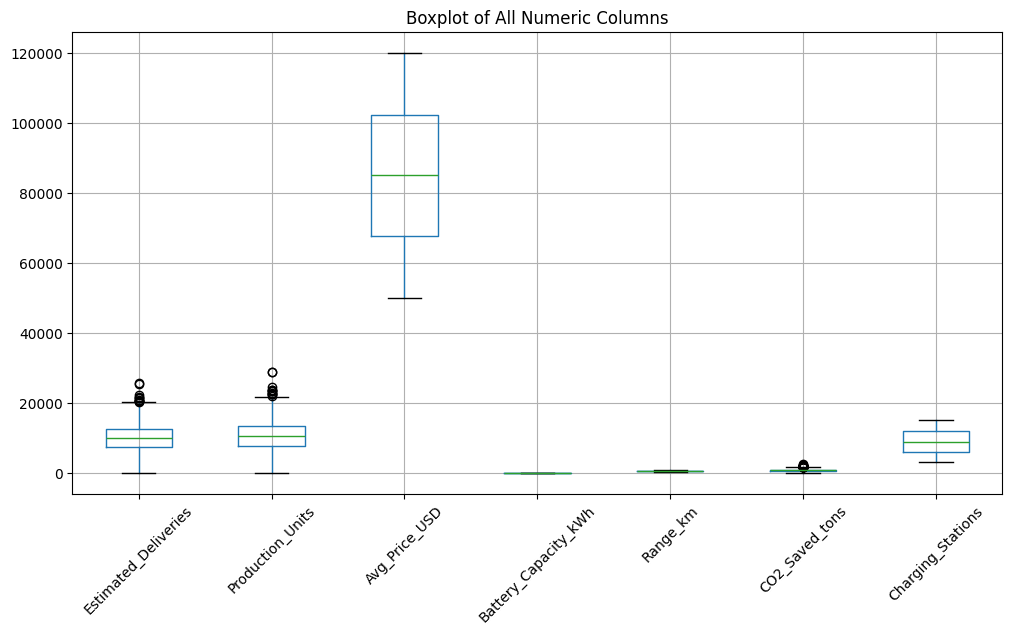

In [ ]:
df.boxplot(figsize=(12, 6))
plt.title("Boxplot of All Numeric Columns")
plt.xticks(rotation=45)
plt.show()

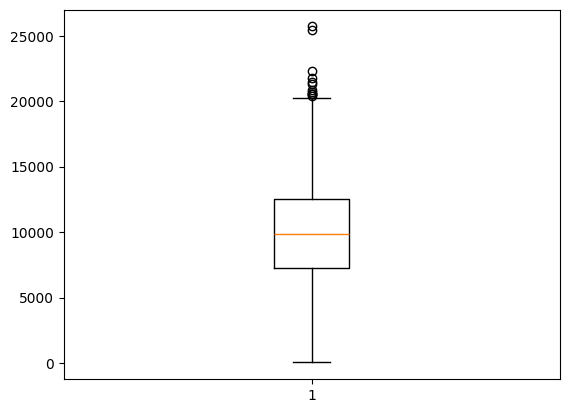

In [ ]:
plt.boxplot(df['Estimated_Deliveries'])
plt.show()

In [ ]:
Q1 = df["Estimated_Deliveries"].quantile(0.25)
Q3 = df["Estimated_Deliveries"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df["Estimated_Deliveries"] < lower_bound) | (df["Estimated_Deliveries"] > upper_bound)]

print(outliers)


      Year Month         Region    Model  Estimated_Deliveries  \
117   2022    11    Middle East  Model Y                 21296   
206   2022    10         Europe  Model 3                 20841   
281   2015     3           Asia  Model 3                 25410   
725   2015     6    Middle East  Model Y                 22315   
729   2018     4         Europe  Model X                 21473   
808   2015    10         Europe  Model S                 20529   
1318  2016     9         Europe  Model S                 20358   
1341  2017    12  North America  Model 3                 25704   
1456  2021     2  North America  Model X                 20568   
2092  2016    12           Asia  Model S                 20577   
2142  2022     1  North America  Model S                 20667   
2490  2022     5         Europe  Model Y                 21772   

      Production_Units  Avg_Price_USD  Battery_Capacity_kWh  Range_km  \
117              23581       57673.97                    60       35

In [ ]:
# Calculate Q1 (25th percentile) and Q3 (75th percentile)
Q1 = df["Production_Units"].quantile(0.25)
Q3 = df["Production_Units"].quantile(0.75)
IQR = Q3 - Q1

# Define lower and upper bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter only the outliers
outliers_prod = df[(df["Production_Units"] < lower_bound) | (df["Production_Units"] > upper_bound)]

# Print the outlier rows
print(outliers_prod)


      Year Month         Region       Model  Estimated_Deliveries  \
117   2022    11    Middle East     Model Y                 21296   
206   2022    10         Europe     Model 3                 20841   
281   2015     3           Asia     Model 3                 25410   
725   2015     6    Middle East     Model Y                 22315   
729   2018     4         Europe     Model X                 21473   
777   2020     7    Middle East  Cybertruck                 20003   
1341  2017    12  North America     Model 3                 25704   
1456  2021     2  North America     Model X                 20568   
1837  2021    11           Asia  Cybertruck                 19764   
2140  2015    11    Middle East     Model 3                 20107   
2142  2022     1  North America     Model S                 20667   
2490  2022     5         Europe     Model Y                 21772   

      Production_Units  Avg_Price_USD  Battery_Capacity_kWh  Range_km  \
117              23581       

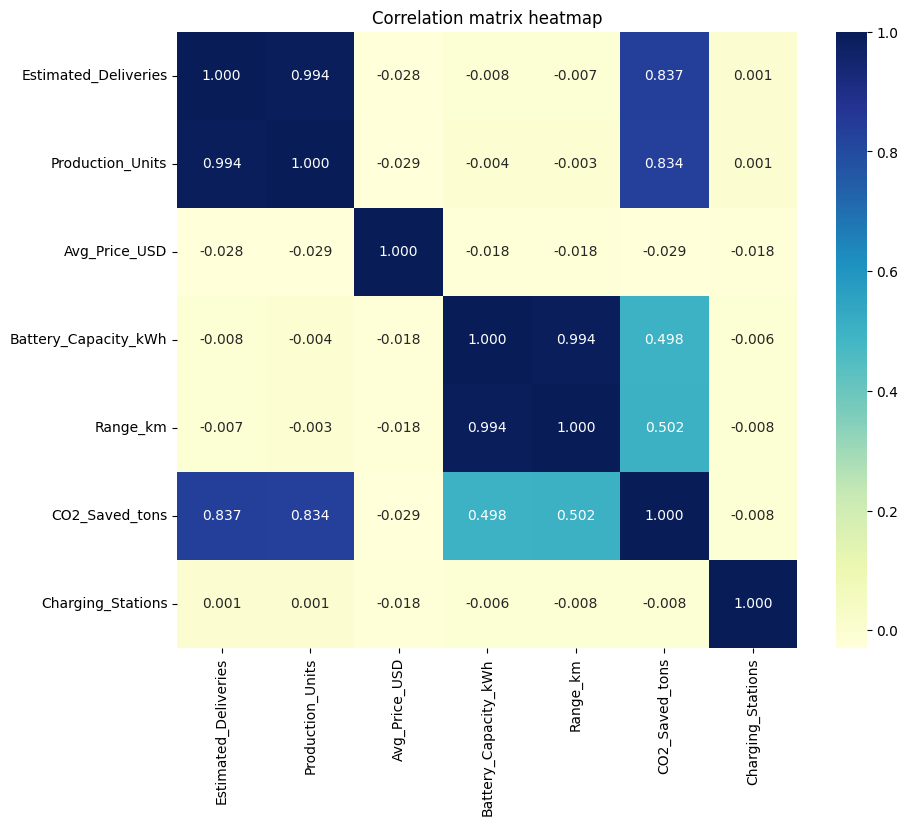

In [ ]:
plt.figure(figsize=(10, 8))
correlation_matrix = df.corr(numeric_only=True)
sns.heatmap(correlation_matrix,annot=True,cmap="YlGnBu",fmt=".3f") #coolwarm , viridis, plasma , magma , cividis , YlGnBu
plt.title("Correlation matrix heatmap")
plt.show()


In [ ]:
df['Date'] = pd.to_datetime(df[['Year', 'Month']].assign(day=1))


In [ ]:

df['Production_Efficiency'] = (df['Estimated_Deliveries'] / df['Production_Units']) * 100
df['Price_per_kWh'] = df['Avg_Price_USD'] / df['Battery_Capacity_kWh']
df['Range_Efficiency'] = df['Range_km'] / df['Battery_Capacity_kWh']

print("Dataset Overview:")
print(f"Shape: {df.shape}")
print(f"Date range: {df['Year'].min()} - {df['Year'].max()}")
print(f"Regions: {df['Region'].unique()}")
print(f"Models: {df['Model'].unique()}")
print("\nFirst few rows:")
print(df.head())

Dataset Overview:
Shape: (2640, 16)
Date range: 2015 - 2025
Regions: ['Europe' 'Asia' 'North America' 'Middle East']
Models: ['Model S' 'Model X' 'Model 3' 'Model Y' 'Cybertruck']

First few rows:
   Year Month         Region    Model  Estimated_Deliveries  Production_Units  \
0  2023     5         Europe  Model S                 17646             17922   
1  2015     2           Asia  Model X                  3797              4164   
2  2019     1  North America  Model X                  8411              9189   
3  2021     2  North America  Model 3                  6555              7311   
4  2016    12    Middle East  Model Y                 12374             13537   

   Avg_Price_USD  Battery_Capacity_kWh  Range_km  CO2_Saved_tons  \
0       92874.27                   120       704         1863.42   
1       62205.65                    75       438          249.46   
2      117887.32                    82       480          605.59   
3       89294.91                   120      

In [ ]:
#Year based Aggregation

annual_deliveries = df.groupby('Year')['Estimated_Deliveries'].sum()
annual_production = df.groupby('Year')['Production_Units'].sum()
annual_co2 = df.groupby('Year')['CO2_Saved_tons'].sum()
annual_avg_price = df.groupby('Year')['Avg_Price_USD'].mean()
battery_evolution = df.groupby('Year')['Battery_Capacity_kWh'].mean()

In [ ]:
print(annual_deliveries)

Year
2015    2375267
2016    2434081
2017    2350517
2018    2423104
2019    2404230
2020    2280336
2021    2335116
2022    2434220
2023    2382375
2024    2406899
2025    2368462
Name: Estimated_Deliveries, dtype: int64


In [ ]:
model_totals = df.groupby('Model')['Estimated_Deliveries'].sum().sort_values(ascending=True)
model_avg_price = df.groupby('Model')['Avg_Price_USD'].mean()
model_avg_range = df.groupby('Model')['Range_km'].mean()
model_avg_battery = df.groupby('Model')['Battery_Capacity_kWh'].mean()
model_co2_total = df.groupby('Model')['CO2_Saved_tons'].sum()

In [ ]:
region_totals = df.groupby('Region')['Estimated_Deliveries'].sum().sort_values(ascending=False)
region_avg_price = df.groupby('Region')['Avg_Price_USD'].mean()
region_co2_total = df.groupby('Region')['CO2_Saved_tons'].sum()
region_charging_avg = df.groupby('Region')['Charging_Stations'].mean()
region_production_total = df.groupby('Region')['Production_Units'].sum()

In [ ]:
region_infrastructure = df.groupby('Region').agg({
    'Charging_Stations': 'mean',
    'Estimated_Deliveries': 'sum',
    'Avg_Price_USD': 'mean',
    'CO2_Saved_tons': 'sum'
}).reset_index()

In [ ]:
print(region_infrastructure)

          Region  Charging_Stations  Estimated_Deliveries  Avg_Price_USD  \
0           Asia        8822.693939               6539935   85161.733773   
1         Europe        9028.990909               6494035   86107.731939   
2    Middle East        9026.512121               6698045   84535.999091   
3  North America        8850.337879               6462592   83823.896515   

   CO2_Saved_tons  
0       484357.26  
1       485135.79  
2       503797.14  
3       491073.06  


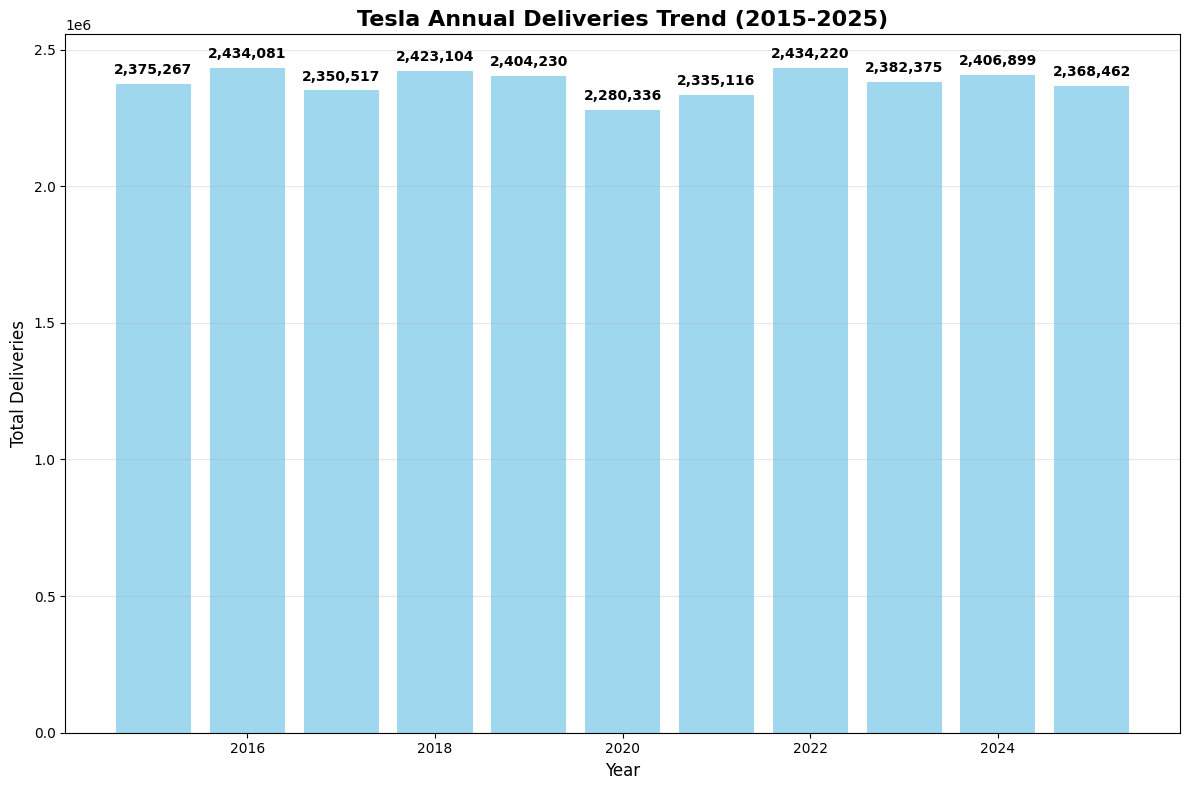

In [ ]:
plt.figure(figsize=(12, 8))

plt.bar(annual_deliveries.index, annual_deliveries.values, color='skyblue', alpha=0.8)
plt.title('Tesla Annual Deliveries Trend (2015-2025)', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total Deliveries', fontsize=12)
plt.grid(axis='y', alpha=0.3)

for i, v in enumerate(annual_deliveries.values):                                  # Adding value labels
  plt.text(annual_deliveries.index[i], v + max(annual_deliveries.values)*0.01,
    f'{v:,.0f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(12, 8))

months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
              'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

plt.plot(range(1, 13), monthly_avg_deliveries.values, marker='o', linewidth=3, markersize=8, color='green')
plt.fill_between(range(1, 13), monthly_avg_deliveries.values, alpha=0.3, color='lightgreen')

plt.title('Tesla Average Monthly Deliveries Pattern', fontsize=16, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Average Deliveries', fontsize=12)
plt.xticks(range(1, 13), months)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

NameError: name 'monthly_avg_deliveries' is not defined

<Figure size 1200x800 with 0 Axes>

In [ ]:
jplt.figure(figsize=(10, 6))

plt.barh(model_totals.index, model_totals.values, color='coral', alpha=0.8)
plt.title('Tesla Total Deliveries by Model', fontsize=16, fontweight='bold')
plt.xlabel('Total Deliveries', fontsize=12)
plt.ylabel('Model', fontsize=12)
plt.grid(axis='x', alpha=0.3)

# Add value labels
for i, v in enumerate(model_totals.values):
  plt.text(v + max(model_totals.values)*0.01, i, f'{v:,.0f}',va='center', fontweight='bold')

plt.tight_layout()
plt.show()

NameError: name 'jplt' is not defined

In [ ]:
plt.figure(figsize=(10, 5))

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']
plt.pie(region_totals.values, labels=region_totals.index, autopct='%1.1f%%',
        startangle=90, colors=colors, explode=(0.05, 0, 0, 0))

plt.title('Tesla Market Share by Region', fontsize=16, fontweight='bold')

# Add total deliveries info
total = region_totals.sum()
plt.figtext(0.02, 0.02, f'Total Deliveries: {total:,.0f}', fontsize=10, style='italic')

plt.axis('equal')
plt.tight_layout()
plt.show()

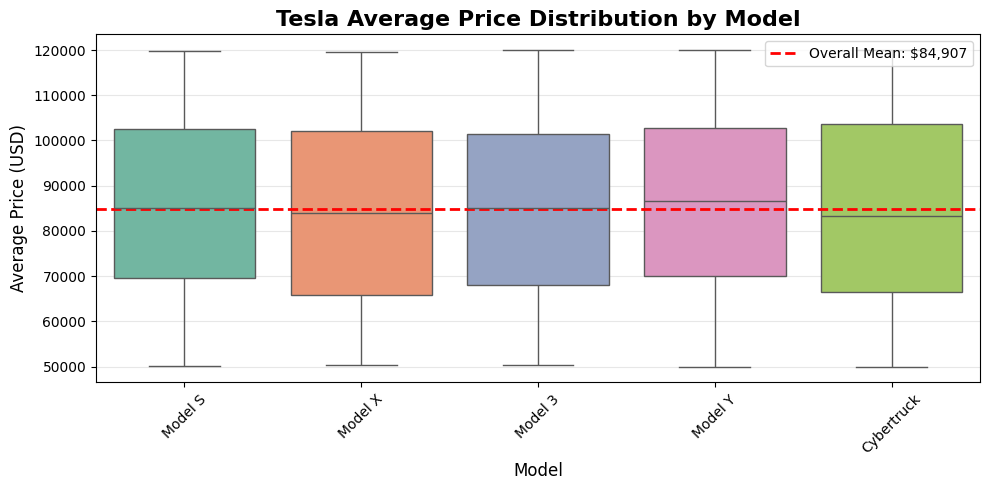

In [ ]:
plt.figure(figsize=(10, 5))

# Box plot by model
sns.boxplot(data=df, x='Model', y='Avg_Price_USD', palette='Set2')
plt.title('Tesla Average Price Distribution by Model', fontsize=16, fontweight='bold')
plt.xlabel('Model', fontsize=12)
plt.ylabel('Average Price (USD)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

# Add mean price line
overall_mean = df['Avg_Price_USD'].mean()
plt.axhline(overall_mean, color='red', linestyle='--', linewidth=2,
            label=f'Overall Mean: ${overall_mean:,.0f}')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
print(model_avg_battery)

Model
Cybertruck    86.931818
Model 3       87.696970
Model S       87.151515
Model X       87.142045
Model Y       86.375000
Name: Battery_Capacity_kWh, dtype: float64


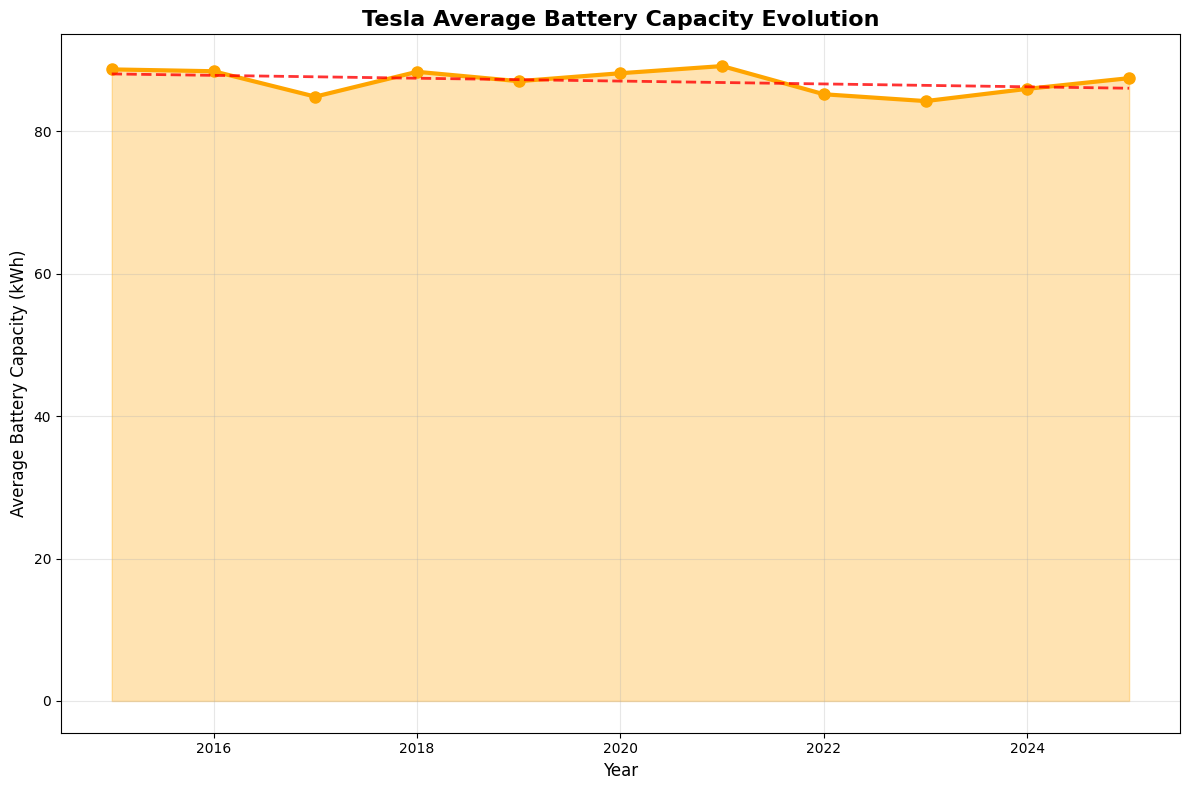

In [ ]:
plt.figure(figsize=(12, 8))

plt.plot(battery_evolution.index, battery_evolution.values, marker='o',
         linewidth=3, markersize=8, color='orange')
plt.fill_between(battery_evolution.index, battery_evolution.values, alpha=0.3, color='orange')

plt.title('Tesla Average Battery Capacity Evolution', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Average Battery Capacity (kWh)', fontsize=12)
plt.grid(True, alpha=0.3)

# Add trend line
z = np.polyfit(battery_evolution.index, battery_evolution.values, 1)
p = np.poly1d(z)
plt.plot(battery_evolution.index, p(battery_evolution.index), "r--", alpha=0.8, linewidth=2 )

plt.tight_layout()
plt.show()

In [ ]:
df

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date,Production_Efficiency,Price_per_kWh,Range_Efficiency
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207,2023-05-01,98.459993,773.952250,5.866667
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640,2015-02-01,91.186359,829.408667,5.840000
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071,2019-01-01,91.533355,1437.650244,5.853659
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333,2021-02-01,89.659417,744.124250,5.933333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722,2016-12-01,91.408732,957.056500,5.508333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2635,2021,10,Middle East,Model Y,13488,14333,113771.10,120,719,1454.68,Official (Quarter),4273,2021-10-01,94.104514,948.092500,5.991667
2636,2019,7,Middle East,Model S,18300,18407,81889.67,82,487,1336.81,Official (Quarter),9833,2019-07-01,99.418699,998.654512,5.939024
2637,2019,9,Asia,Model S,13291,14839,97139.38,100,580,1156.32,Estimated (Region),13709,2019-09-01,89.568030,971.393800,5.800000
2638,2020,5,Asia,Cybertruck,3471,3714,69990.57,60,358,186.39,Interpolated (Month),6754,2020-05-01,93.457189,1166.509500,5.966667


In [ ]:

df.to_excel("Tesla-excel.xlsx", index=False)
from google.colab import files
files.download("Tesla-excel.xlsx")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**MACHINE LEARNING**-
RANDOM FOREST REEGRESSION


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Load dataset
df = pd.read_excel("Tesla-excel.xlsx")

# INPUT FEATURES (numeric only for simplicity)
X = df[
    [
        'Year',
        'Month',
        'Production_Units',
        'Avg_Price_USD',
        'Battery_Capacity_kWh',
        'Range_km',
        'Charging_Stations',
        'Production_Efficiency'
    ]
]

# OUTPUT
y = df['Estimated_Deliveries']

# 70% Train, 30% Test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Random Forest Model
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Train model
model.fit(X_train, y_train)

# Predict on test data
y_pred = model.predict(X_test)

# Predict for one sample
new_prediction = model.predict([X_test.iloc[9]])
print("Predicted Deliveries:", int(new_prediction[0]))

# Evaluation
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mse)

print("Mean Squared Error:", mse)
print("R² Score:", r2)
print("RMSE:",rmse)


Predicted Deliveries: 7615
Mean Squared Error: 22278.542419444446
R² Score: 0.9985491252238089
RMSE: 149.25998264586676


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [ ]:
print("\nEnter New Car Specifications:")

year = int(input("Year: "))
month = int(input("Month: "))
production_units = int(input("Production Units: "))
avg_price = float(input("Average Price (USD): "))
battery_capacity = int(input("Battery Capacity (kWh): "))
range_km = int(input("Range (km): "))
charging_stations = int(input("Charging Stations: "))
production_efficiency = float(input("Production Efficiency: "))

new_car_specs = pd.DataFrame(
    [[
        year,
        month,
        production_units,
        avg_price,
        battery_capacity,
        range_km,
        charging_stations,
        production_efficiency
    ]],
    columns=X.columns
)

predicted_delivery = model.predict(new_car_specs)

# Show input + output together
result = new_car_specs.copy()
result['Predicted_Deliveries'] = int(predicted_delivery[0])

print("\nPrediction Result:")
print(result.to_string(index=False))



Enter New Car Specifications:
Year: 2023
Month: 5
Production Units: 17922	
Average Price (USD): 92874.27
Battery Capacity (kWh): 120
Range (km): 704
Charging Stations: 12207
Production Efficiency: 98.459993

Prediction Result:
 Year  Month  Production_Units  Avg_Price_USD  Battery_Capacity_kWh  Range_km  Charging_Stations  Production_Efficiency  Predicted_Deliveries
 2023      5             17922       92874.27                   120       704              12207              98.459993                 17437


In [ ]:
df


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date,Production_Efficiency,Price_per_kWh,Range_Efficiency
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207,2023-05-01,98.459993,773.952250,5.866667
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640,2015-02-01,91.186359,829.408667,5.840000
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071,2019-01-01,91.533355,1437.650244,5.853659
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333,2021-02-01,89.659417,744.124250,5.933333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722,2016-12-01,91.408732,957.056500,5.508333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2635,2021,10,Middle East,Model Y,13488,14333,113771.10,120,719,1454.68,Official (Quarter),4273,2021-10-01,94.104514,948.092500,5.991667
2636,2019,7,Middle East,Model S,18300,18407,81889.67,82,487,1336.81,Official (Quarter),9833,2019-07-01,99.418699,998.654512,5.939024
2637,2019,9,Asia,Model S,13291,14839,97139.38,100,580,1156.32,Estimated (Region),13709,2019-09-01,89.568030,971.393800,5.800000
2638,2020,5,Asia,Cybertruck,3471,3714,69990.57,60,358,186.39,Interpolated (Month),6754,2020-05-01,93.457189,1166.509500,5.966667


# **Predicting Price**

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Load dataset
df = pd.read_excel("Tesla-excel.xlsx")

# Convert categorical variables to numerical using one-hot encoding
df_encoded = pd.get_dummies(df, columns=['Model', 'Region'], drop_first=True)

# INPUT FEATURES
P = df_encoded[
    [
        'Year',
        'Month',
        'Production_Units',
        'Battery_Capacity_kWh',
        'Range_km',
        'Charging_Stations',
        'Production_Efficiency'
    ] + [col for col in df_encoded.columns if 'Model_' in col or 'Region_' in col]
]

# OUTPUT (PRICE)
v = df_encoded['Avg_Price_USD']

# Train-test split (70–30)
P_train, P_test, v_train, v_test = train_test_split(
    P, v, test_size=0.3, random_state=42
)

# Model
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Train
model.fit(P_train, v_train)

# Evaluation
v_pred = model.predict(P_test)
print("MSE:", mean_squared_error(v_test, v_pred))
print("R² Score:", r2_score(v_test, v_pred))

# --------------------------------
# TYPE INPUT IN OUTPUT BOX
# --------------------------------

print("\nEnter Car Specifications to Predict PRICE:")

year = int(input("Year: "))
month = int(input("Month: "))
production_units = int(input("Production Units: "))
battery_capacity = int(input("Battery Capacity (kWh): "))
range_km = int(input("Range (km): "))
charging_stations = int(input("Charging Stations: "))
production_efficiency = float(input("Production Efficiency: "))
model_input = input("Model (e.g., Model 3, Model S, Model X, Model Y, Cybertruck): ")
region_input = input("Region (e.g., Asia, Europe, Middle East, North America): ")

# Create a DataFrame for new car specs, ensuring all one-hot encoded columns are present
new_car_data = {
    'Year': [year],
    'Month': [month],
    'Production_Units': [production_units],
    'Battery_Capacity_kWh': [battery_capacity],
    'Range_km': [range_km],
    'Charging_Stations': [charging_stations],
    'Production_Efficiency': [production_efficiency]
}

# Initialize all one-hot encoded columns to 0
for col in P.columns:
    if 'Model_' in col or 'Region_' in col:
        new_car_data[col] = [0]

# Set the value to 1 for the specified model and region
if f'Model_{model_input}' in new_car_data:
    new_car_data[f'Model_{model_input}'] = [1]
if f'Region_{region_input}' in new_car_data:
    new_car_data[f'Region_{region_input}'] = [1]

new_car_specs = pd.DataFrame(new_car_data, columns=P.columns)

# Predict price
predicted_price = model.predict(new_car_specs)

# Display result
result = new_car_specs.copy()
result['Predicted_Avg_Price_USD'] = round(predicted_price[0], 2)

print("\nPrediction Result:")
print(result.to_string(index=False))


MSE: 384653585.755837
R² Score: -0.03932367978917428

Enter Car Specifications to Predict PRICE:


KeyboardInterrupt: Interrupted by user

The inputs are not much correlated with the target variable , need to add model and region name
